In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

In [2]:
data = {
    "Student": ["A", "B", "C", "D", "E", "F"],
    "Math": [85, 90, 78, 92, 88, 76],
    "Science": [80, 85, 75, 90, 82, 70],
}

df = pd.DataFrame(data)
print(df)

  Student  Math  Science
0       A    85       80
1       B    90       85
2       C    78       75
3       D    92       90
4       E    88       82
5       F    76       70


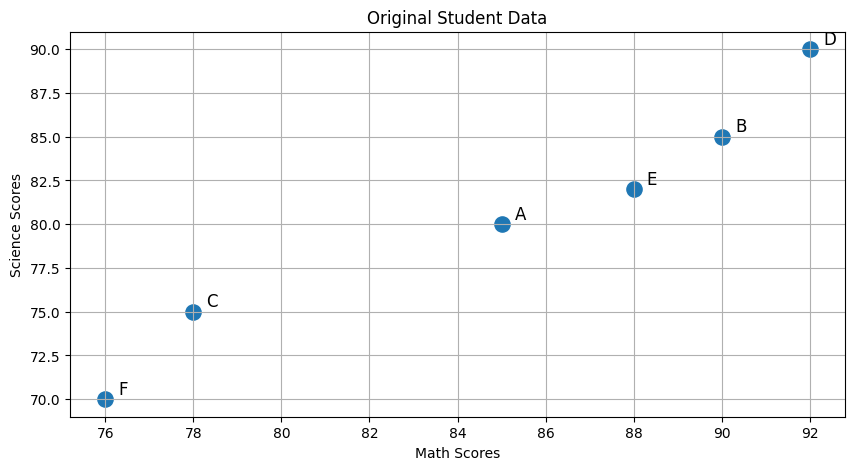

In [3]:
plt.figure(figsize=(10, 5))

plt.scatter(df["Math"], df["Science"], s=120)
for i in range(len(df)):
    plt.text(df["Math"][i] + 0.3,
              df["Science"][i] + 0.3,
                df["Student"][i],
                  fontsize=12)

plt.xlabel("Math Scores")
plt.ylabel("Science Scores")
plt.title("Original Student Data")
plt.grid(True)

plt.show()

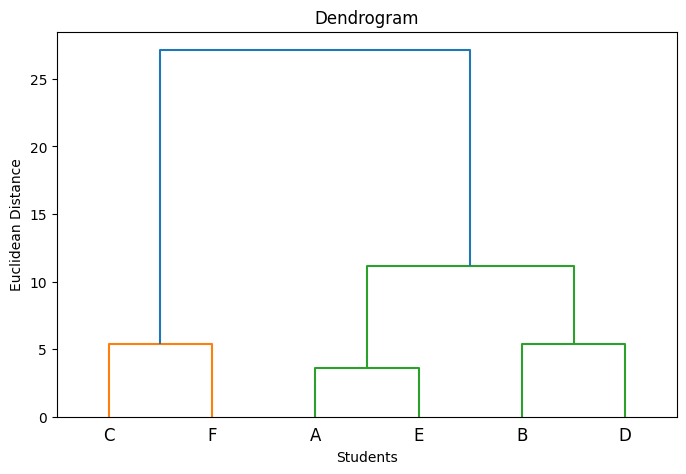

In [5]:
plt.figure(figsize=(8, 5))

X = df[["Math", "Science"]].values
linkage_matrix = linkage(X, method='ward')

dendrogram(linkage_matrix, labels=df["Student"].values)

plt.title("Dendrogram")
plt.xlabel("Students")
plt.ylabel("Euclidean Distance")
plt.show()

In [8]:
#applying agglomerative clustering

model = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward'
)

clusters = model.fit_predict(X)

df['Cluster'] = clusters

print(df)

  Student  Math  Science  Cluster
0       A    85       80        0
1       B    90       85        0
2       C    78       75        1
3       D    92       90        0
4       E    88       82        0
5       F    76       70        1


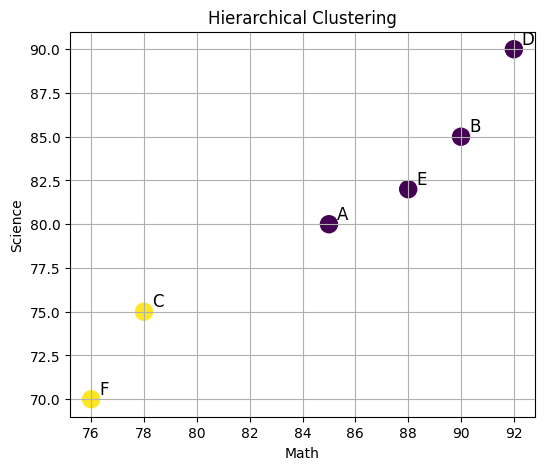

In [10]:
#plot clusters
plt.figure(figsize=(6, 5))
plt.scatter(df["Math"],
             df["Science"],
               c=df["Cluster"],
                 cmap='viridis',
                   s=150)
for i in range(len(df)):
    plt.text(df["Math"][i] + 0.3,
              df["Science"][i] + 0.3,
                df["Student"][i],
                  fontsize=12)

plt.xlabel("Math")
plt.ylabel("Science")
plt.title("Hierarchical Clustering")

plt.grid(True)
plt.show()

In [14]:
#Predict cluster for a new student

model = KMeans(n_clusters=2)
model.fit(X)

new_student = [[80, 82]]  # Math: 80, Science: 82
print(model.predict(new_student))  # Output: [0] or [1] depending on the cluster

[0]
